# Green *Vitis vinifera* Grape Berry — Developmental Stage Comparison

**Phase 1C:** Characterise the *pre-veraison* (green) *V. vinifera* berry GEM and compare it with the mature berry model to contextualise the developmental metabolic reprogramming relevant to *A. niger* infection susceptibility.

---
* **Author:** Joana Maia
* **Solver:** Gurobi (Academic Licence)
* **Core libraries:** COBRApy · Pandas · Seaborn · Matplotlib
* **Model:** *iMS7199* — *V. vinifera* green berry (SBML Level $3$)

---

## 1. Environment Setup
### 1.1 Package Installation

In [1]:
# !pip install cobra
# !pip install gurobipy
# !pip install matplotlib
# !pip install pandas
# !pip install seaborn

### 1.2 Library Imports and Version Audit

In [2]:
# Standard library
import os
import html as html_lib
import warnings
warnings.filterwarnings('ignore')

# Numerical / data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# COBRApy and flux analysis tools
import cobra
from cobra.flux_analysis import (find_blocked_reactions, find_essential_genes, find_essential_reactions, flux_variability_analysis, production_envelope)
from cobra.io import read_sbml_model, write_sbml_model
import gurobipy

# Version audit
print(f'COBRApy    : {cobra.__version__}')
print(f'Gurobi     : {".".join(str(v) for v in gurobipy.gurobi.version())}')
print(f'Matplotlib : {matplotlib.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Seaborn    : {sns.__version__}')

COBRApy    : 0.31.1
Gurobi     : 13.0.2
Matplotlib : 3.10.8
NumPy      : 2.4.4
Pandas     : 2.3.3
Seaborn    : 0.13.2


### 1.3 Global Plotting Style

In [3]:
sns.set_theme(style = 'whitegrid', context = 'notebook', font_scale = 1.1)
plt.rcParams.update({'figure.dpi'         : 120,
                     'axes.spines.top'    : False,
                     'axes.spines.right'  : False,
                     'figure.autolayout'  : True})
PALETTE_MAIN = 'BuPu_r'
PALETTE_CAT  = sns.color_palette('BuPu_r', 8) 

### 1.4 Model Loading
Load *iMS7199* green berry (`3_iMS7199_berry_green.xml`) and the curated mature berry model (`VvM_mature_curated.xml`, produced by Phase 1B) into COBRApy for comparative analysis.

In [4]:
GREEN_PATH  = '3_iMS7199_berry_green.xml'
MATURE_PATH = 'VvM_mature_curated.xml'    # produced by Phase 1B

for p in [GREEN_PATH, MATURE_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f'Model file not found: {p}')

green_raw   = read_sbml_model(GREEN_PATH)
green_model = green_raw.copy()

print(green_model)
print(f'\nUnconstrained μ (green_raw): {green_raw.optimize().objective_value:.4f} h⁻¹')

mature_raw = read_sbml_model(MATURE_PATH)
mature_model = mature_raw.copy()

print(mature_model)
print(f'\nUnconstrained μ (mature_raw): {mature_raw.optimize().objective_value:.4f} h⁻¹')

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2747228
Academic license 2747228 - for non-commercial use only - registered to pg___@uminho.pt
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmpd30pwufr.lp
Reading time = 0.02 seconds
: 4399 rows, 8996 columns, 38116 nonzeros
vvinif2023

Unconstrained μ (green_raw): 0.1446 h⁻¹
Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmprxcngaxt.lp
Reading time = 0.01 seconds
: 5143 rows, 8544 columns, 35884 nonzeros
vvinif2023

Unconstrained μ (mature_raw): 0.1541 h⁻¹


In [5]:
def _find_exchange(keywords):
    for rxn in green_model.exchanges:
        if any(k.upper() in rxn.id.upper() for k in keywords):
            return rxn.id
    return None

SUCROSE_RXN = _find_exchange(['SUCROSE'])          or 'EX_SUCROSE_drain'
O2_RXN      = _find_exchange(['OXYGEN'])           or 'EX_OXYGEN-MOLECULE_drain'
NO3_RXN     = _find_exchange(['NITRATE'])          or 'EX_NITRATE_drain'
BIOMASS_ID  = [r.id for r in green_model.reactions if 'biomass' in r.id.lower()
               and 'drain' not in r.id.lower()][0]

print(f'SUCROSE_RXN : {SUCROSE_RXN}')
print(f'O₂_RXN      : {O2_RXN}')
print(f'NO₃_RXN     : {NO3_RXN}')
print(f'BIOMASS_ID  : {BIOMASS_ID}')

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.
Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.
Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


SUCROSE_RXN : EX_SUCROSE_drain
O₂_RXN      : EX_OXYGEN-MOLECULE_drain
NO₃_RXN     : EX_NITRATE_drain
BIOMASS_ID  : e-Biomass_vvinif2023__cyto


### 1.5 Curation: Compartment Remapping and Reaction ID Curation

The raw green berry model uses numeric compartment codes (`C001`–`C010`) and contains $218$ reaction IDs that begin with digits or `+/-` prefixes — both incompatible with Gurobi's LP variable naming convention. Two curation steps are applied:

1. **Compartment remapping:** codes replaced with semantic identifiers (`cytosol_plant`, `chloro_plant`, etc.).
2. **Reaction renaming:** problematic IDs prefixed with `R_`.

Both steps are verified to leave the biomass flux ($\mu = 0.1446\, h^{-1}$) unchanged.

In [6]:
COMPARTMENT_MAP = {'C001': 'cytosol_plant',
                   'C002': 'pmf_plant',
                   'C003': 'chloro_plant',
                   'C004': 'mito_plant',
                   'C005': 'er_plant',
                   'C006': 'perox_plant',
                   'C007': 'golgi_plant',
                   'C008': 'vacuole_plant',
                   'C009': 'e',
                   'C010': 'lumen_plant',}

pre_cur_mu = green_model.optimize().objective_value
print(f'μ before curation : {pre_cur_mu:.4f} h⁻¹')

# 1. Compartment remapping
for met in green_model.metabolites:
    if met.compartment in COMPARTMENT_MAP:
        met.compartment = COMPARTMENT_MAP[met.compartment]
green_model.compartments = {v: v for v in COMPARTMENT_MAP.values()}

# 2. Reaction ID renaming
renamed_green = []
for rxn in green_model.reactions:
    if rxn.id[0].isdigit() or rxn.id[:2] in ('--', '+-'):
        rxn.id = 'R_' + rxn.id.lstrip('-+')
        renamed_green.append(rxn.id)
print(f'Reactions renamed : {len(renamed_green)}')

post_cur = green_model.optimize()
assert post_cur.status == 'optimal',                          'Model infeasible after curation.'
assert abs(post_cur.objective_value - pre_cur_mu) < 1e-6,     'Curation changed μ!'
assert 'e' in green_model.compartments,                       'Extracellular compartment missing.'
assert len(renamed_green) > 0,                                'No reactions were renamed!'

print(f'μ after curation  : {post_cur.objective_value:.4f} h⁻¹.')
print(f'Compartments      : {sorted(green_model.compartments.keys())}')
print(f'R_ renamed        : {len(renamed_green)} reactions.')

μ before curation : 0.1446 h⁻¹
Reactions renamed : 218
μ after curation  : 0.1446 h⁻¹.
Compartments      : ['chloro_plant', 'cytosol_plant', 'e', 'er_plant', 'golgi_plant', 'lumen_plant', 'mito_plant', 'perox_plant', 'pmf_plant', 'vacuole_plant']
R_ renamed        : 218 reactions.


## 2. Global Characterisation

### 2.1 Optimal Flux Simulation via FBA

The green berry model is feasible and reaches a maximum biomass flux of $\mu = 0.1446\, h^{-1}$, driven by sucrose uptake ($1.0\, mmol/gDW/h$) and aerobic respiration (O₂ uptake $3.71\, mmol/gDW/h$). Nitrate is the primary nitrogen source ($0.99\, mmol/gDW/h$). The unconstrained growth rate is $6.6\%$ lower than the mature berry ($0.1541\, h^{-1}$), consistent with the higher biosynthetic demands of the *pre-veraison* developmental stage.

In [7]:
fba_green = green_model.optimize()
print(f'FBA status            : {fba_green.status}')
print(f'Unconstrained μ (h⁻¹) : {fba_green.objective_value:.4f}')

O2_BASELINE_GREEN  = abs(fba_green.fluxes.get(O2_RXN,  0.0))
NO3_BASELINE_GREEN = abs(fba_green.fluxes.get(NO3_RXN, 0.0))
SUC_BASELINE_GREEN = abs(fba_green.fluxes.get(SUCROSE_RXN, 0.0))
print(f'\nSucrose uptake : {SUC_BASELINE_GREEN:.4f} mmol/gDW/h')
print(f'O₂ uptake      : {O2_BASELINE_GREEN:.4f} mmol/gDW/h')
print(f'NO₃ uptake     : {NO3_BASELINE_GREEN:.4f} mmol/gDW/h')

FBA status            : optimal
Unconstrained μ (h⁻¹) : 0.1446

Sucrose uptake : 1.0000 mmol/gDW/h
O₂ uptake      : 3.7134 mmol/gDW/h
NO₃ uptake     : 0.9907 mmol/gDW/h


In [8]:
rxn = green_model.reactions.get_by_id(BIOMASS_ID)
print(f'Objective reaction : {rxn.id}')
print(f'Name               : {rxn.name}')
print(f'Direction          : {green_model.objective.direction}')
print(f'Bounds             : [{rxn.lower_bound}, {rxn.upper_bound}]')
print(f'Full objective     : {green_model.objective.expression}')
print(f'Reactants          : {[m.id for m in rxn.reactants]}')
print(f'Products           : {[m.id for m in rxn.products]}')
print(f'\nEquation: {rxn.reaction}')

Objective reaction : e-Biomass_vvinif2023__cyto
Name               : e-Biomass_vvinif2023
Direction          : max
Bounds             : [0.0, 10000.0]
Full objective     : 1.0*e-Biomass_vvinif2023__cyto - 1.0*e-Biomass_vvinif2023__cyto_reverse_ab9d5
Reactants          : ['e-Protein__cyto', 'e-Lipids__cyto', 'e-DNA__cyto', 'e-RNA__cyto', 'e-Carbohydrates__cyto', 'e-Cofactor__cyto', 'e-CellWall__cyto', 'ATP__cyto', 'WATER__cyto']
Products           : ['e-Biomass__cyto', 'ADP__cyto', 'Pi__cyto']

Equation: 53.26 ATP__cyto + 53.26 WATER__cyto + 0.25 e-Carbohydrates__cyto + 0.25 e-CellWall__cyto + 0.012 e-Cofactor__cyto + 0.003 e-DNA__cyto + 0.08 e-Lipids__cyto + 0.401 e-Protein__cyto + 0.004 e-RNA__cyto --> 53.26 ADP__cyto + 53.26 Pi__cyto + e-Biomass__cyto


| Component      | Green berry | Mature berry | Δ (M − G)  | Biological interpretation                        |
|----------------|-------------|--------------|------------|--------------------------------------------------|
| ATP            | 53.26       | 53.26        |  0.000     | Identical energy cost                            |
| H₂O            | 53.26       | 53.26        |  0.000     | Identical                                        |
| Protein        | 0.401       | 0.600        | +0.199     | Higher protein content at maturation             |
| Carbohydrates  | 0.250       | 0.300        | +0.050     | Higher sugar accumulation at maturation          |
| Lipids         | 0.080       | 0.042        | −0.038     | Reduced membrane biosynthesis at maturation      |
| Cell Wall      | 0.250       | 0.050        | −0.200     | Major cell wall remodelling at *veraison*        |
| Cofactor       | 0.012       | 0.001        | −0.011     | Reduced cofactor demand at maturation            |
| DNA            | 0.003       | 0.003        |  0.000     | Identical                                        |
| RNA            | 0.004       | 0.004        |  0.000     | Identical                                        |

## 3. Cross-Stage Comparison: Green vs. Mature Berry

The mature berry model (`VvM_mature_curated.xml`, produced by Phase 1B) is loaded for direct comparison. All analyses use the same solver (Gurobi) and COBRApy version to ensure methodological consistency.

### 3.1 Global Network Statistics

Model size, blocked and essential reaction fractions are compared side-by-side to characterise the structural differences between developmental stages.

The green berry model has $223$ more reactions but $744$ fewer metabolites than the mature model, resulting in a lower met/rxn ratio ($0.98$ vs $1.20$) — consistent with a less integrated, more open metabolic network at the *pre-veraison* stage. The biomass flux is slightly lower ($+0.0095\, h^{-1}$ at maturation), reflecting metabolic rewiring rather than a fundamental capacity change. Both models have a comparable proportion of blocked reactions ($48.1\%$ in the green berry, $46.4\%$ in the mature), confirming that large portions of the *iMS7199* reconstruction are context-inactive regardless of developmental
stage.

In [9]:
# Model size
n_rxns_g,  n_mets_g,  n_genes_g  = (len(green_model.reactions),
                                    len(green_model.metabolites),
                                    len(green_model.genes))
n_rxns_m,  n_mets_m,  n_genes_m  = (len(mature_model.reactions),
                                    len(mature_model.metabolites),
                                    len(mature_model.genes))

# Biomass objective
bio_g = [r for r in green_model.reactions
         if 'biomass' in r.id.lower() and 'drain' not in r.id.lower()][0]
bio_m = [r for r in mature_model.reactions
         if 'biomass' in r.id.lower() and 'drain' not in r.id.lower()][0]

print('Biomass objectives:')
print(f'    Green  : {bio_g.id}')
print(f'    Mature : {bio_m.id}')
print(f'        Bounds (green)  : [{bio_g.lower_bound}, {bio_g.upper_bound}]')
print(f'        Bounds (mature) : [{bio_m.lower_bound}, {bio_m.upper_bound}]')
print()

# FBA
fba_green  = green_model.optimize()
fba_mature = mature_model.optimize()

# Blocked
blocked_ids_g = find_blocked_reactions(green_model,  processes = 1)
blocked_ids_m = find_blocked_reactions(mature_model, processes = 1)

# Essential reactions
ess_ids_g = {r.id for r in find_essential_reactions(green_model,  processes = 1)}
ess_ids_m = {r.id for r in find_essential_reactions(mature_model, processes = 1)}

# Comparison table
stats = pd.DataFrame({'Metric': ['Reactions',
                                 'Metabolites',
                                 'Genes',
                                 'Compartments',
                                 'Met/Rxn ratio',
                                 'Biomass flux (h⁻¹)',
                                 'Blocked reactions',
                                 'Blocked (%)',
                                 'Essential reactions',
                                 'Essential (%)'],
                      'Green berry': [n_rxns_g,
                                      n_mets_g,
                                      n_genes_g,
                                      len(green_model.compartments),
                                      f'{n_mets_g/n_rxns_g:.2f}',
                                      f'{fba_green.objective_value:.4f}',
                                      len(blocked_ids_g),
                                      f'{len(blocked_ids_g)/n_rxns_g*100:.1f}%',
                                      len(ess_ids_g),
                                      f'{len(ess_ids_g)/n_rxns_g*100:.1f}%'],
                      'Mature berry': [n_rxns_m,
                                       n_mets_m,
                                       n_genes_m,
                                       len(mature_model.compartments),
                                       f'{n_mets_m/n_rxns_m:.2f}',
                                       f'{fba_mature.objective_value:.4f}',
                                       len(blocked_ids_m),
                                       f'{len(blocked_ids_m)/n_rxns_m*100:.1f}%',
                                       len(ess_ids_m),
                                       f'{len(ess_ids_m)/n_rxns_m*100:.1f}%'],
                      'Delta (M − G)': [n_rxns_m  - n_rxns_g,
                                        n_mets_m  - n_mets_g,
                                        n_genes_m - n_genes_g,
                                        len(mature_model.compartments) - len(green_model.compartments),
                                        f'{n_mets_m/n_rxns_m - n_mets_g/n_rxns_g:.3f}',
                                        f'{fba_mature.objective_value - fba_green.objective_value:+.4f}',
                                        len(blocked_ids_m) - len(blocked_ids_g),
                                        f'{(len(blocked_ids_m)/n_rxns_m - len(blocked_ids_g)/n_rxns_g)*100:+.1f}%',
                                        len(ess_ids_m) - len(ess_ids_g),
                                        f'{(len(ess_ids_m)/n_rxns_m - len(ess_ids_g)/n_rxns_g)*100:+.1f}%'],})

print(stats.to_string(index = False))

Biomass objectives:
    Green  : e-Biomass_vvinif2023__cyto
    Mature : e-Biomass_vvinif2023_berry_mature__cyto
        Bounds (green)  : [0.0, 10000.0]
        Bounds (mature) : [0.0, 10000.0]

             Metric Green berry Mature berry Delta (M − G)
          Reactions        4495         4272          -223
        Metabolites        4399         5143           744
              Genes        6657         7199           542
       Compartments          10           10             0
      Met/Rxn ratio        0.98         1.20         0.225
 Biomass flux (h⁻¹)      0.1446       0.1541       +0.0095
  Blocked reactions        2161         1984          -177
        Blocked (%)       48.1%        46.4%         -1.6%
Essential reactions         317          334            17
      Essential (%)        7.1%         7.8%         +0.8%


### 3.2 Gene Essentiality Cross-Stage Comparison

Of the $74$ genes essential in the mature berry, $73$ ($98.6\%$) are also essential in the green berry. Only $1$ gene gains essentiality at maturation, and no gene loses essentiality — the essential metabolic core is virtually identical across developmental stages.

This high conservation reflects the indispensability of central metabolic functions regardless of the growth-vs-maintenance shift at *veraison*.

The single gene acquiring essentiality at maturation is **Vitvi02g00435\_t001**, whose mechanistic basis was traced in full. The gene exclusively catalyses RXN-7785 (anthocyanidin biosynthesis; GPR without isozyme alternative), which supplies CPD-7090 to RXN-7815, whose product CPD-7117 is a required component of the mature berry carbohydrate biomass fraction (`e-Carbohydrates_vvinif2023_berry_mature`). Knockout of RXN-7785 reduces $\mu$ from $0.1541$ to $0.0000\, h^{-1}$ (complete lethality) in the mature model. An alternative CPD-7090 source (RXN-9723) exists in both models but cannot compensate, likely due to limited CPD-10411 availability or an unfavourable redox balance in the mature network context.

In the green berry, the CPD-7117 anthocyanin fraction is absent from the biomass composition — consistent with the well-established absence of anthocyanin accumulation before *veraison* — rendering the entire branch flux-zero and the gene dispensable. This result constitutes a model-level recapitulation of one of the most characterised molecular events of the *veraison* transition in *V. vinifera*, and is consistent with Vitvi02g00435\_t001 encoding **Anthocyanidin Synthase (ANS/LDOX)**, the 2-oxoglutarate-dependent dioxygenase responsible for the first committed step in anthocyanin pigment biosynthesis.

This result has a direct and positive implication for *A. niger* infection modelling: antifungal gene targets identified in the mature berry context are **transferable to green berry physiology with high confidence**, since the essential gene sets overlap by $98.6\%$. Stage-specific target design is therefore only necessary for Vitvi02g00435\_t001.

In [10]:
green_for_ess  = green_model.copy()
mature_for_ess = mature_model.copy()

essential_genes_g = find_essential_genes(green_for_ess,  processes=1)
essential_genes_m = find_essential_genes(mature_for_ess, processes=1)

essential_gids_g = {g.id for g in essential_genes_g}   
essential_gids_m = {g.id for g in essential_genes_m}

n_ess_g = len(essential_gids_g)
n_ess_m = len(essential_gids_m)
print(f'Essential genes (green) : {n_ess_g}')
print(f'Essential genes (mature): {n_ess_m}')

green_only_ess  = essential_gids_g - essential_gids_m
mature_only_ess = essential_gids_m - essential_gids_g
shared_ess      = essential_gids_g & essential_gids_m
n_neither       = len(green_model.genes) - len(green_only_ess) - len(mature_only_ess) - len(shared_ess)

print(f'\nGene Essentiality Cross-Stage Comparison')
print(f'{"_"*50}')
print(f'  Essential in green only  : {len(green_only_ess):>4}')
print(f'  Essential in mature only : {len(mature_only_ess):>4}')
print(f'  Essential in BOTH        : {len(shared_ess):>4}')
print(f'  Non-essential in both    : {n_neither:>4}')
print(f'\nGenes gaining essentiality at maturation : {len(mature_only_ess)}')
print(f'Genes losing  essentiality at maturation : {len(green_only_ess)}')

Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmpn_r_fyog.lp
Reading time = 0.01 seconds
: 4399 rows, 8996 columns, 38116 nonzeros
Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmpbpegxv3_.lp
Reading time = 0.01 seconds
: 5143 rows, 8544 columns, 35884 nonzeros
Essential genes (green) : 73
Essential genes (mature): 74

Gene Essentiality Cross-Stage Comparison
__________________________________________________
  Essential in green only  :    0
  Essential in mature only :    1
  Essential in BOTH        :   73
  Non-essential in both    : 6583

Genes gaining essentiality at maturation : 1
Genes losing  essentiality at maturation : 0


In [11]:
# Identify the gene that gains essentiality during maturation
TARGET_GENE = list(mature_only_ess)[0]
gene_obj    = mature_model.genes.get_by_id(TARGET_GENE)

print(f'\nGene ID   : {TARGET_GENE}')
print(f'Gene name : {gene_obj.name}')
print(f'Reactions : {len(gene_obj.reactions)}')

# Reactions associated with the target gene
for rxn in gene_obj.reactions:
    has_alternative = ' or ' in rxn.gene_reaction_rule.lower()
    flux_g = fba_green.fluxes.get(rxn.id, 0)
    flux_m = fba_mature.fluxes.get(rxn.id, 0)
    print(f'\n  {rxn.id}')
    print(f'    Subsystem         : {rxn.subsystem}')
    print(f'    Equation          : {rxn.reaction}')
    print(f'    GPR               : {rxn.gene_reaction_rule}')
    print(f'    Isozyme exists    : {has_alternative}')
    print(f'    FBA flux (green)  : {flux_g:.6f} mmol/gDW/h')
    print(f'    FBA flux (mature) : {flux_m:.6f} mmol/gDW/h')

# Identify the reaction without isozyme alternative
sole_rxn_id = 'RXN-7785__cyto'
print(f'\nSole-gene reaction: {sole_rxn_id}')
print('   No isozyme alternative → this is the essentiality bottleneck.')

# Trace CPD-7090 (direct product)
cpd7090 = mature_model.metabolites.get_by_id('CPD-7090__cyto')
for rxn in cpd7090.reactions:
    role      = 'PRODUCED' if rxn.metabolites[cpd7090] > 0 else 'CONSUMED'
    flux_m    = fba_mature.fluxes.get(rxn.id, 0)
    flux_g    = fba_green.fluxes.get(rxn.id, 0)
    blocked_m = rxn.id in blocked_ids_m
    blocked_g = rxn.id in blocked_ids_g
    print(f'\n  [{role}] {rxn.id}')
    print(f'    Equation          : {rxn.reaction}')
    print(f'    GPR               : {rxn.gene_reaction_rule}')
    print(f'    FBA flux (green)  : {flux_g:.6f}  blocked = {blocked_g}')
    print(f'    FBA flux (mature) : {flux_m:.6f}  blocked = {blocked_m}')

# Trace CPD-7117 (downstream product → biomass link)
bio_rxn_m_id = [r.id for r in mature_model.reactions
                if 'biomass' in r.id.lower() and 'drain' not in r.id.lower()][0]
bio_rxn_g_id = [r.id for r in green_model.reactions
                if 'biomass' in r.id.lower() and 'drain' not in r.id.lower()][0]

cpd7117_mature = mature_model.metabolites.get_by_id('CPD-7117__cyto')
cpd7117_in_biomass_m = cpd7117_mature in mature_model.reactions.get_by_id(bio_rxn_m_id).metabolites

try:
    cpd7117_green        = green_model.metabolites.get_by_id('CPD-7117__cyto')
    cpd7117_in_biomass_g = cpd7117_green in green_model.reactions.get_by_id(bio_rxn_g_id).metabolites
except:
    cpd7117_in_biomass_g = False

print(f'\n  CPD-7117 in mature biomass : {cpd7117_in_biomass_m}')
print(f'  CPD-7117 in green  biomass : {cpd7117_in_biomass_g}')
for rxn in cpd7117_mature.reactions:
    if rxn.metabolites[cpd7117_mature] < 0:
        flux_m = fba_mature.fluxes.get(rxn.id, 0)
        tag    = '← BIOMASS' if rxn.id == bio_rxn_m_id else ''
        print(f'    {rxn.id:50s} flux = {flux_m:.6f}  {tag}')
        print(f'      Subsystem: {rxn.subsystem}')

# Direct knockout simulation
with mature_model:
    mature_model.reactions.get_by_id(sole_rxn_id).knock_out()
    ko_sol = mature_model.optimize()
    delta_mu = ko_sol.objective_value - fba_mature.objective_value
    print(f'\n  μ (wild-type) : {fba_mature.objective_value:.6f} h⁻¹')
    print(f'  μ (knockout)  : {ko_sol.objective_value:.6f} h⁻¹  status = {ko_sol.status}')
    print(f'  Δμ            : {delta_mu:+.6f} h⁻¹')
    print(f'  Lethal        : {ko_sol.objective_value < 1e-6}')

with green_model:
    try:
        green_model.reactions.get_by_id(sole_rxn_id).knock_out()
        ko_sol_g = green_model.optimize()
        delta_mu_g = ko_sol_g.objective_value - fba_green.objective_value
        print(f'\n  μ (wild-type) : {fba_green.objective_value:.6f} h⁻¹')
        print(f'  μ (knockout)  : {ko_sol_g.objective_value:.6f} h⁻¹  status = {ko_sol_g.status}')
        print(f'  Δμ            : {delta_mu_g:+.6f} h⁻¹')
        print(f'  Lethal        : {ko_sol_g.objective_value < 1e-6}')
    except:
        print('  RXN-7785__cyto not present in green model.')


Gene ID   : Vitvi02g00435_t001
Gene name : G_Vitvi02g00435_t001
Reactions : 4

  RXN-8450__cyto
    Subsystem         : flavonol biosynthesis
    Equation          : 2-KETOGLUTARATE__cyto + CPD-7087__cyto + OXYGEN-MOLECULE__cyto --> CARBON-DIOXIDE__cyto + MYRICETIN__cyto + SUC__cyto + WATER__cyto
    GPR               : Vitvi18g02542_t001 or Vitvi18g00307_t001 or Vitvi18g02543_t001 or Vitvi18g02541_t001 or Vitvi18g02541_t002 or Vitvi18g02538_t001 or Vitvi02g00435_t001 or Vitvi08g00656_t001 or Vitvi02g00270_t001 or Vitvi02g00270_t003 or Vitvi02g00270_t002 or Vitvi03g01312_t002 or Vitvi03g01312_t001 or Vitvi13g00055_t001 or Vitvi15g00871_t001 or Vitvi13g01119_t004 or Vitvi13g01119_t002 or Vitvi13g01119_t003 or Vitvi13g01119_t001 or Vitvi16g01336_t003 or Vitvi16g01336_t001 or Vitvi08g01235_t001 or Vitvi07g00587_t001 or Vitvi11g00565_t002 or Vitvi11g00565_t001 or Vitvi05g00295_t001 or Vitvi13g00329_t001 or Vitvi02g01474_t001 or Vitvi08g01236_t001 or Vitvi02g01472_t001 or Vitvi11g00564_t00

### 3.3 Flux Variability Analysis

FVA was performed at the optimal growth rate ($\text{fraction\_of\_optimum} = 1.0$) to quantify the metabolic flexibility available to each stage while maintaining maximum biomass flux.

At optimality, $75.3\%$ of green berry reactions are fixed (range $< 10^{-6}$), compared to $72.5\%$ in the mature model — indicating that both networks operate
with a highly constrained flux distribution at their respective growth optima. The fixed fraction is substantially higher than the blocked reaction fraction
($48.1\%$ and $46.4\%$), confirming that an additional $\sim 27\%$ of reactions are feasible but stoichiometrically locked at optimality: they can
carry flux in principle, but only one flux value is consistent with maximum growth. The median reaction range of $0.0000\, mmol/gDW/h$ in both models reflects this rigidity — more than half of all reactions admit no variability at the optimum.

The mature berry retains slightly more flexibility ($23.2\%$ flexible reactions vs $20.8\%$ in the green), consistent with the metabolic redundancy expected in
a maintenance-oriented network. Unbounded metabolic reactions ($31$ green, $38$ mature; $0.7\%$ and $0.9\%$ respectively) are a minor fraction and likely
reflect reactions in subsystems disconnected from the biomass objective under the current medium constraints. No numerically unstable reactions were detected
in either model.

In [12]:
# Green berry FVA
with green_model:
    fva_g_full = flux_variability_analysis(green_model, fraction_of_optimum = 1.0, processes = 1)

# Mature berry FVA
with mature_model:
    fva_m_full = flux_variability_analysis(mature_model, fraction_of_optimum = 1.0, processes = 1)

DEFAULT_BOUND_G = 10000.0
DEFAULT_BOUND_M = 10000.0
transport_prefixes = ('TR', 'TO', 'TZ', 'T_')

def fva_summary(fva, default_bound, model_name):
    fva = fva.copy()
    fva['range'] = fva['maximum'] - fva['minimum']
    unbounded     = fva[(fva['minimum'] <= -default_bound) & (fva['maximum'] >= default_bound)]
    unbounded_met = unbounded[~unbounded.index.str.startswith(transport_prefixes)]
    n_fixed       = (fva['range'] < 1e-6).sum()
    n_flexible    = len(fva) - n_fixed - len(unbounded)
    nan_rxns      = fva[fva['minimum'].isna() | fva['maximum'].isna()]
    print(f'\nFVA summary — {model_name} (fraction_of_optimum = 1.0):')
    print(f'    Numerically unstable reactions    : {len(nan_rxns):>5}')
    print(f'    Fixed reactions (range < 1e-6)    : {n_fixed:>5} ({n_fixed/len(fva)*100:.1f}%)')
    print(f'    Flexible reactions                : {n_flexible:>5} ({n_flexible/len(fva)*100:.1f}%)')
    print(f'    Unbounded transport reactions     : {len(unbounded)-len(unbounded_met):>5}')
    print(f'    Unbounded metabolic reactions     : {len(unbounded_met):>5} ({len(unbounded_met)/len(fva)*100:.1f}%)')
    print(f'    Median range                      : {fva["range"].median():.4f} mmol/gDW/h')
    return fva

fva_g_full = fva_summary(fva_g_full, DEFAULT_BOUND_G, 'Green berry')
fva_m_full = fva_summary(fva_m_full, DEFAULT_BOUND_M, 'Mature berry')


FVA summary — Green berry (fraction_of_optimum = 1.0):
    Numerically unstable reactions    :     0
    Fixed reactions (range < 1e-6)    :  3385 (75.3%)
    Flexible reactions                :   934 (20.8%)
    Unbounded transport reactions     :   145
    Unbounded metabolic reactions     :    31 (0.7%)
    Median range                      : 0.0000 mmol/gDW/h

FVA summary — Mature berry (fraction_of_optimum = 1.0):
    Numerically unstable reactions    :     0
    Fixed reactions (range < 1e-6)    :  3102 (72.6%)
    Flexible reactions                :   984 (23.0%)
    Unbounded transport reactions     :   148
    Unbounded metabolic reactions     :    38 (0.9%)
    Median range                      : 0.0000 mmol/gDW/h


### 3.4 Blocked Reaction Profile — Subsystem Comparison

Blocked reactions are identified and mapped to subsystems, then compared between green and mature stages to reveal which metabolic pathways are developmentally silenced or activated at *veraison*.

$2161$ reactions are blocked in the green berry ($48.1\%$), compared to $1984$ in the mature model ($46.4\%$). The differential analysis reveals two distinct categories:

- **Developmentally silenced at maturation** (more blocked in mature): caffeine and theobromine biosynthesis, fusaric acid, menthol biosynthesis, and several xenobiotic pathways — all consistent with the shutdown of secondary metabolism associated with *pre-veraison* tissue.
- **Newly active at maturation** (unblocked in mature): aurone biosynthesis, catecholamine biosynthesis, pterocarpan biosynthesis, and δ-carotene biosynthesis — secondary metabolites characteristic of ripening and stress response in mature berries.

**Note:** several subsystems carry non-plant database labels (e.g., *S. pneumoniae*, cyanobacteria) reflecting annotation artefacts in *iMS7199*, with no functional impact on flux calculations.

Blocked reactions: 2161 (48.1% of 4495)


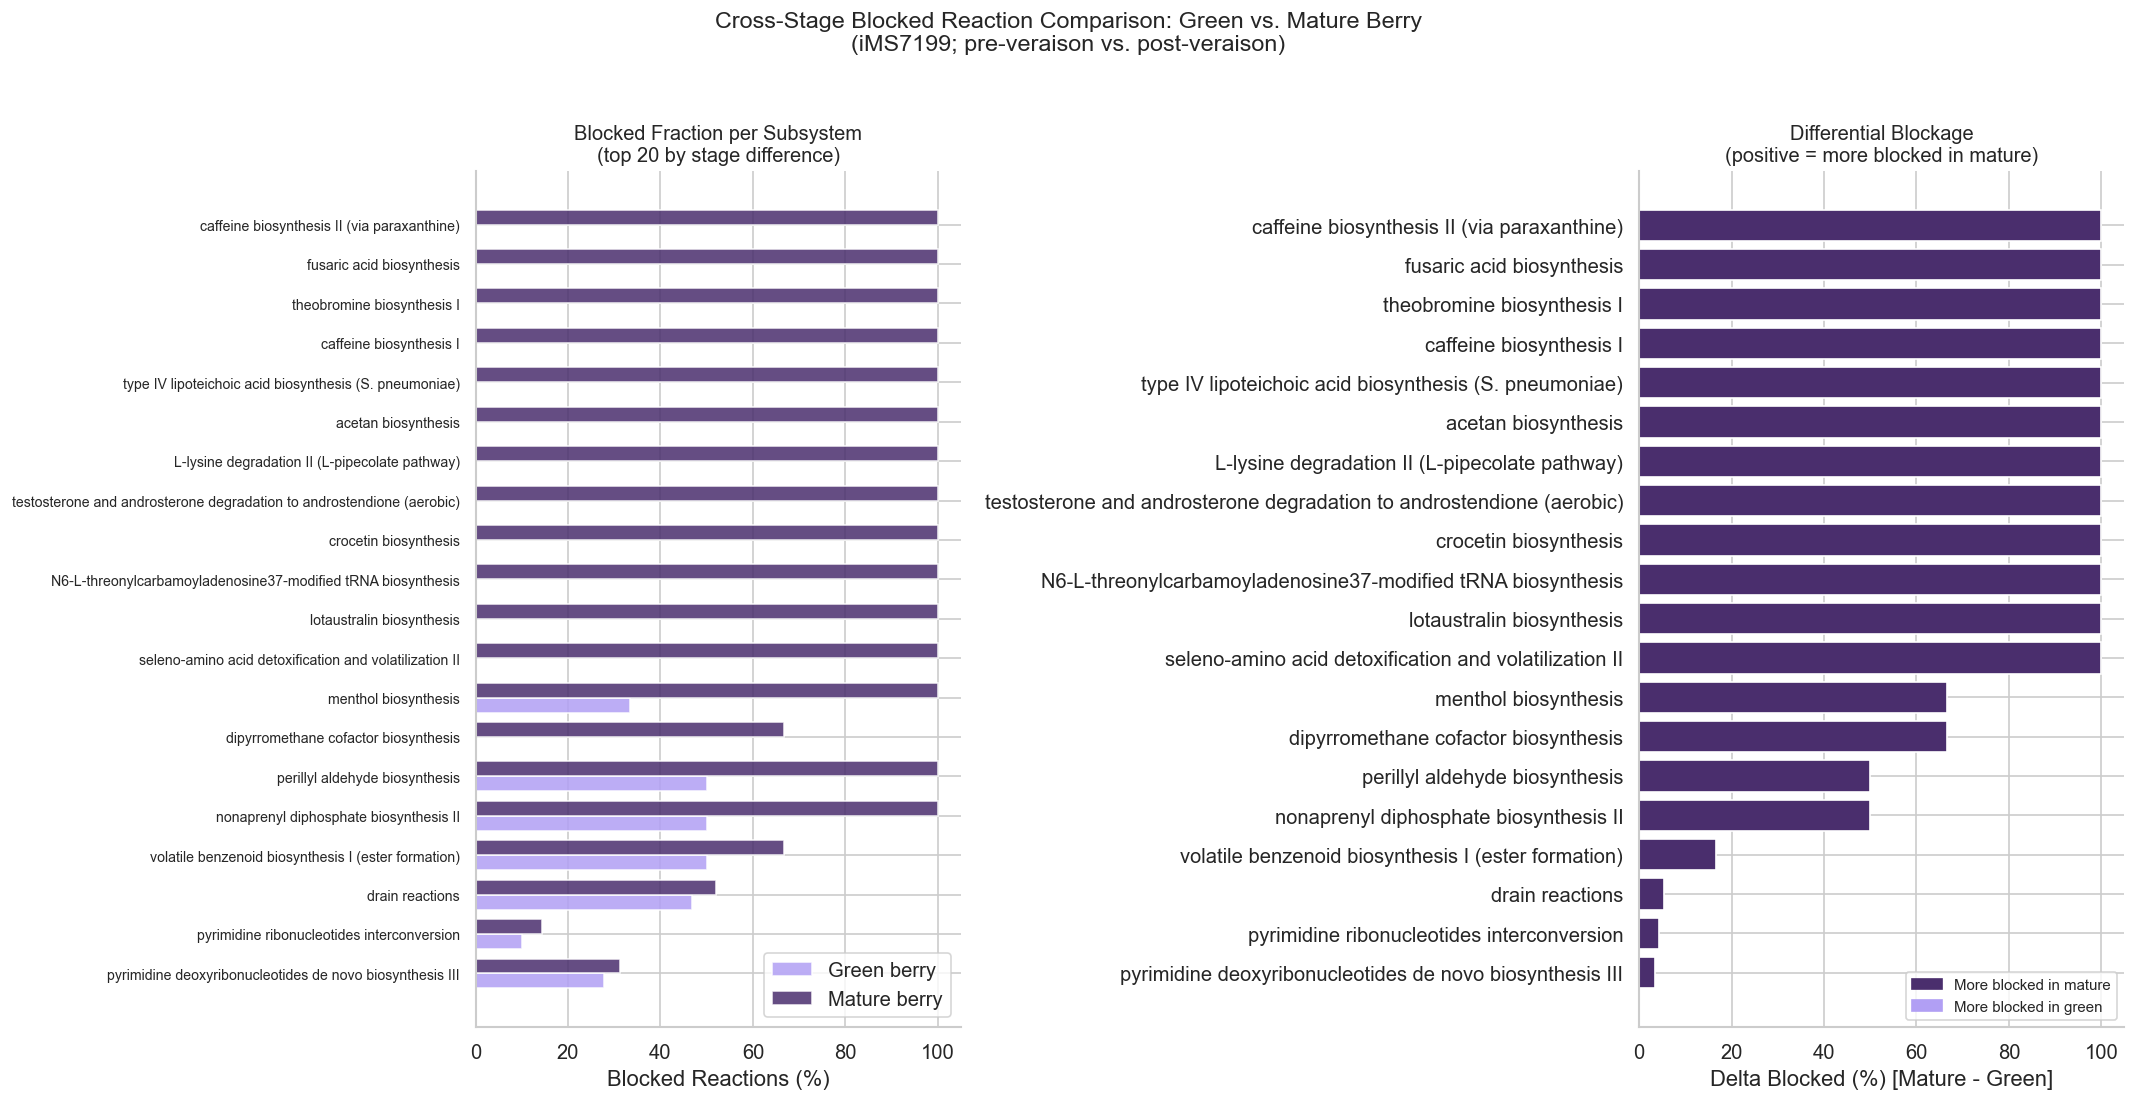


Subsystems gaining blockage from green to mature (developmentally silenced):
                                                            Subsystem  Blocked_G_pct  Blocked_M_pct      Delta
                          caffeine biosynthesis II (via paraxanthine)       0.000000     100.000000 100.000000
                                            fusaric acid biosynthesis       0.000000     100.000000 100.000000
                                           theobromine biosynthesis I       0.000000     100.000000 100.000000
                                              caffeine biosynthesis I       0.000000     100.000000 100.000000
               type IV lipoteichoic acid biosynthesis (S. pneumoniae)       0.000000     100.000000 100.000000
                                                  acetan biosynthesis       0.000000     100.000000 100.000000
                       L-lysine degradation II (L-pipecolate pathway)       0.000000     100.000000 100.000000
testosterone and androsterone degr

In [13]:
blocked_ids_g = find_blocked_reactions(green_model, processes=1)
n_blocked_g   = len(blocked_ids_g)
print(f'Blocked reactions: {n_blocked_g} ({n_blocked_g/n_rxns_g*100:.1f}% of {n_rxns_g})')

blocked_subsys_g = (pd.Series([green_model.reactions.get_by_id(rid).subsystem or 'Unclassified'
                               for rid in blocked_ids_g])
                               .value_counts().rename_axis('Subsystem').reset_index())
blocked_subsys_g.columns = ['Subsystem', 'Blocked']
total_per_subsys_g = (pd.Series([r.subsystem or 'Unclassified' for r in green_model.reactions])
                      .value_counts().rename_axis('Subsystem').reset_index())
total_per_subsys_g.columns = ['Subsystem', 'Total']
blocked_merged_g = (blocked_subsys_g.merge(total_per_subsys_g, on = 'Subsystem')
                    .assign(**{'Blocked (%)': lambda d: d['Blocked']/d['Total']*100})
                    .sort_values('Blocked (%)', ascending = False))

blocked_subsys_m = (pd.Series([mature_model.reactions.get_by_id(rid).subsystem or 'Unclassified'
                               for rid in blocked_ids_m])
                               .value_counts().rename_axis('Subsystem').reset_index())
blocked_subsys_m.columns = ['Subsystem', 'Blocked_M']
total_per_subsys_m = (pd.Series([r.subsystem or 'Unclassified' for r in mature_model.reactions])
                      .value_counts().rename_axis('Subsystem').reset_index())
total_per_subsys_m.columns = ['Subsystem', 'Total_M']
blocked_merged_m = (blocked_subsys_m.merge(total_per_subsys_m, on='Subsystem')
                    .assign(**{'Blocked_M_pct': lambda d: d['Blocked_M']/d['Total_M']*100}))

# Merge green and mature blocked profiles
bm_g = blocked_merged_g.rename(columns={'Blocked':'Blocked_G', 'Total':'Total_G', 'Blocked (%)':'Blocked_G_pct'})
bm_m = blocked_merged_m[['Subsystem', 'Blocked_M_pct']]
comparison = (bm_g[['Subsystem', 'Blocked_G_pct']]
              .merge(bm_m, on = 'Subsystem', how = 'outer')
              .fillna(0)
              .assign(Delta = lambda d: d['Blocked_M_pct'] - d['Blocked_G_pct'])
              .sort_values('Delta', ascending = False))

comparison['Subsystem'] = comparison['Subsystem'].apply(html_lib.unescape)

# Top 20 subsystems by absolute difference
top_diff  = comparison.nlargest(20, 'Delta')
fig, axes = plt.subplots(1, 2, figsize = (18, 9))
x         = np.arange(len(top_diff))
w         = 0.38

# Left
bars_g = axes[0].barh(x + w/2, 
                      top_diff['Blocked_G_pct'],
                      height = w, 
                      label  = 'Green berry', 
                      color  = '#B19FF4', 
                      alpha  = 0.85)
bars_m = axes[0].barh(x - w/2, 
                      top_diff['Blocked_M_pct'],
                      height = w, 
                      label  = 'Mature berry', 
                      color  = '#4A2E6D', 
                      alpha  = 0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(top_diff['Subsystem'], fontsize=8.5)
axes[0].set_xlabel('Blocked Reactions (%)')
axes[0].set_title('Blocked Fraction per Subsystem\n(top 20 by stage difference)', fontsize = 12)
axes[0].legend()
axes[0].invert_yaxis()

# Right
colors_d = ['#4A2E6D' if d > 0 else '#B19FF4' for d in top_diff['Delta']]
axes[1].barh(top_diff['Subsystem'], 
             top_diff['Delta'],
             color = colors_d, 
             edgecolor = 'white')
axes[1].axvline(0, color = 'black', lw = 1)
axes[1].set_xlabel('Delta Blocked (%) [Mature - Green]')
axes[1].set_title('Differential Blockage\n(positive = more blocked in mature)', fontsize = 12)
axes[1].invert_yaxis()
axes[1].legend(handles=[mpatches.Patch(color = '#4A2E6D', label = 'More blocked in mature'),
                        mpatches.Patch(color = '#B19FF4', label = 'More blocked in green'),], 
                        fontsize = 9)

plt.suptitle('Cross-Stage Blocked Reaction Comparison: Green vs. Mature Berry\n'
             '(iMS7199; pre-veraison vs. post-veraison)', fontsize = 14, y = 1.02)
plt.tight_layout()
# plt.savefig('fig3_stage_blocked_comparison.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print('\nSubsystems gaining blockage from green to mature (developmentally silenced):')
silenced = comparison[comparison['Delta'] > 20].sort_values('Delta', ascending = False)
print(silenced[['Subsystem','Blocked_G_pct','Blocked_M_pct','Delta']].to_string(index = False))

print('\nSubsystems losing blockage from green to mature (newly active):')
activated = comparison[comparison['Delta'] < -20].sort_values('Delta')
print(activated[['Subsystem','Blocked_G_pct','Blocked_M_pct','Delta']].to_string(index = False))

### 3.5 Exchange Flux Profile Comparison

Active exchange fluxes (FBA optimal, $|flux| > 10^{-6}$) are compared between stages to characterise the differential uptake and secretion profile.

Both stages share sucrose as the sole carbon source ($-1.0\, mmol/gDW/h$). The key differences at maturation are:

- **O₂ uptake decreases** ($-3.71 \to -2.44\, mmol/gDW/h$, $\Delta = +1.27$) — the mature berry relies less on aerobic respiration, consistent with the shift from growth to maintenance metabolism.
- **Ammonium secretion disappears** ($+0.50 \to 0$) — nitrogen recycling is reduced at maturation.
- **H₂O secretion appears** ($0 \to +1.77\, mmol/gDW/h$) — reflects the high water content characteristic of ripe berries.
- **H⁺ uptake increases** ($-3.42 \to -5.34\, mmol/gDW/h$, $\Delta = -1.91$) — the mature berry consumes more protons from the extracellular medium, consistent with the well-characterised rise in berry pH at *veraison* as malate is catabolised and the apoplastic environment becomes less acidic. This is the opposite of acidification: the mature stage model predicts net alkalinisation of the extracellular milieu, which may reduce the competitive advantage of *A. niger* (an acidophilic fungus) relative to the *pre-veraison* context.
- **Hydrogencarbonate secretion decreases** ($+6.20 \to +4.71\, mmol/gDW/h$) — consistent with reduced carbon dioxide production as aerobic respiration declines at maturation.

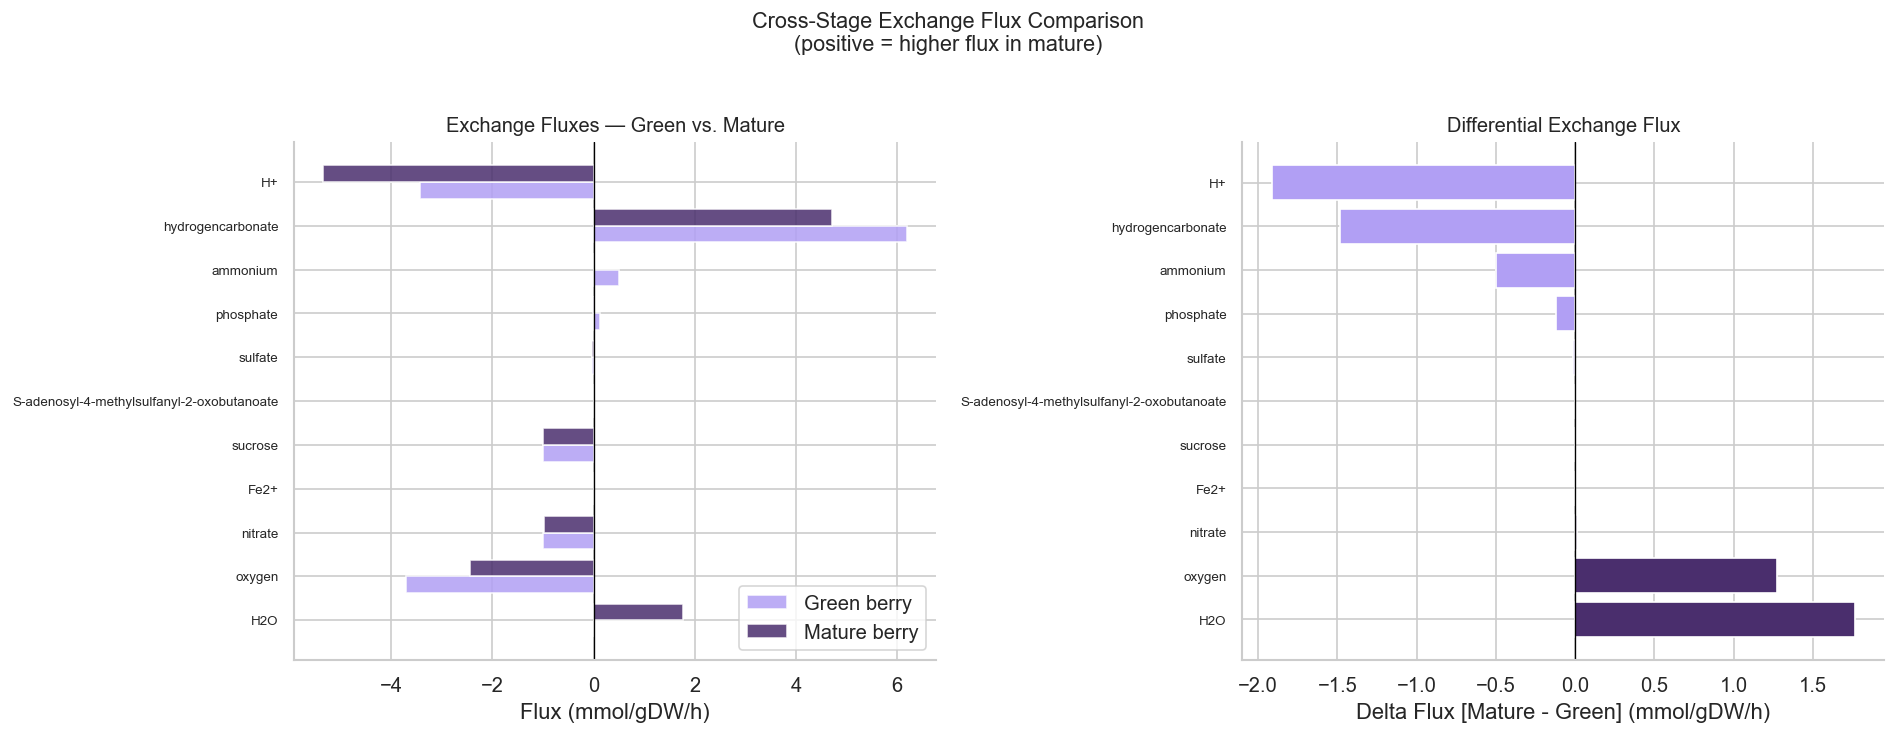

                                               Green    Mature     Delta
Metabolite                                                              
H+                                         -3.423335 -5.338235 -1.914900
hydrogencarbonate                           6.199098  4.714053 -1.485045
ammonium                                    0.499191  0.000000 -0.499191
phosphate                                   0.119716 -0.000117 -0.119832
sulfate                                    -0.020661 -0.032152 -0.011491
S-adenosyl-4-methylsulfanyl-2-oxobutanoate  0.000004  0.000000 -0.000004
sucrose                                    -1.000000 -1.000000  0.000000
Fe2+                                       -0.000002  0.000000  0.000002
nitrate                                    -0.990676 -0.976275  0.014401
oxygen                                     -3.713389 -2.440271  1.273118
H2O                                         0.000000  1.766175  1.766175


In [14]:
def safe_label_m(rid):
    try:
        rxn = mature_model.reactions.get_by_id(rid)
        if rxn.reactants: return html_lib.unescape(rxn.reactants[0].name)
        if rxn.products:  return html_lib.unescape(rxn.products[0].name)
    except: pass
    return rid

def safe_label(rid):
    try:
        rxn = green_model.reactions.get_by_id(rid)
        if rxn.reactants: return html_lib.unescape(rxn.reactants[0].name)
        if rxn.products:  return html_lib.unescape(rxn.products[0].name)
    except: pass
    return rid


ex_fluxes_g = {rxn.id: fba_green.fluxes[rxn.id]
               for rxn in green_model.exchanges
               if abs(fba_green.fluxes.get(rxn.id, 0)) > 1e-6}

df_exch_g = (pd.DataFrame.from_dict(ex_fluxes_g, orient = 'index', columns = ['Flux'])
             .rename_axis('Reaction ID')
             .assign(Direction  = lambda d: d['Flux'].apply(lambda x: 'Uptake' if x<0 else 'Secretion'),
                     Metabolite = lambda d: d.index.map(safe_label))
                     .sort_values('Flux').reset_index())

ex_fluxes_m = {rxn.id: fba_mature.fluxes[rxn.id]
               for rxn in mature_model.exchanges
               if abs(fba_mature.fluxes.get(rxn.id, 0)) > 1e-6}
df_exch_m = (pd.DataFrame.from_dict(ex_fluxes_m, orient = 'index', columns = ['Flux'])
             .assign(Metabolite = lambda d: d.index.map(safe_label_m))
             .rename(columns = {'Flux': 'Mature'})
             [['Metabolite','Mature']]
             .set_index('Metabolite'))
df_exch_g2 = (df_exch_g.set_index('Metabolite')[['Flux']].rename(columns={'Flux': 'Green'}))

comparison_ex = (df_exch_g2.join(df_exch_m, how = 'outer')
                 .fillna(0)
                 .assign(Delta = lambda d: d['Mature'] - d['Green'])
                 .sort_values('Delta'))

fig, axes = plt.subplots(1, 2, figsize = (16, max(6, len(comparison_ex)*0.35)))
x         = np.arange(len(comparison_ex))
w         = 0.38

# Left
axes[0].barh(x + w/2, 
             comparison_ex['Green'],
             height = w, 
             label  = 'Green berry', 
             color  = '#B19FF4', 
             alpha  = 0.85)
axes[0].barh(x - w/2, 
             comparison_ex['Mature'],
             height = w, 
             label  = 'Mature berry', 
             color  = '#4A2E6D', 
             alpha  = 0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(comparison_ex.index, fontsize = 8)
axes[0].axvline(0, color = 'black', lw = 0.8)
axes[0].set_xlabel('Flux (mmol/gDW/h)')
axes[0].set_title('Exchange Fluxes — Green vs. Mature', fontsize = 12)
axes[0].legend()
axes[0].invert_yaxis()

# Right
colors_ex = ['#4A2E6D' if d > 0 else '#B19FF4' for d in comparison_ex['Delta']]
axes[1].barh(comparison_ex.index, 
             comparison_ex['Delta'],
             color = colors_ex, 
             edgecolor = 'white')
axes[1].axvline(0, color = 'black', lw = 0.8)
axes[1].set_xlabel('Delta Flux [Mature - Green] (mmol/gDW/h)')
axes[1].set_title('Differential Exchange Flux', fontsize = 12)
axes[1].invert_yaxis()
axes[1].set_yticklabels(comparison_ex.index, fontsize = 8)

plt.suptitle('Cross-Stage Exchange Flux Comparison\n(positive = higher flux in mature)',
             fontsize = 13, y = 1.02)
plt.tight_layout()
# plt.savefig('fig4_stage_exchange_comparison.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print(comparison_ex[['Green', 'Mature', 'Delta']].to_string())

### 3.6 Shadow Price Comparison — Shift in Limiting Resources

The top-$20$ most limiting metabolites are compared across stages.

$16$ of the $20$ most limiting metabolites are shared between both stages, all within lipid and membrane biosynthesis (cardiolipin, triacylglycerols, acyl-CoA, CDP-diacylglycerol). This indicates that membrane lipid supply is the primary growth-limiting constraint at both developmental stages — a finding consistent with the high lipid demand of rapidly proliferating pre-veraison tissue and the membrane remodelling associated with ripening. The $4$ metabolites unique to each stage reflect stage-specific secondary metabolic demands.

In [15]:
shadow_m = fba_mature.shadow_prices.dropna()
shadow_nonzero_m = shadow_m[shadow_m.abs() > 1e-9]
top_neg_m = shadow_nonzero_m.nsmallest(20)

def met_name_m(mid):
    try: return html_lib.unescape(mature_model.metabolites.get_by_id(mid).name or mid)
    except: return mid

df_shadow_neg_m = pd.DataFrame({'Metabolite' : [met_name_m(i) for i in top_neg_m.index],
                                'ID'         : list(top_neg_m.index),
                                'Shadow_M'   : top_neg_m.values,})

def met_name_g(mid):
    try: return html_lib.unescape(green_model.metabolites.get_by_id(mid).name or mid)
    except: return mid
def met_comp_g(mid):
    try: return green_model.metabolites.get_by_id(mid).compartment
    except: return 'n/a'

shadow_g         = fba_green.shadow_prices.dropna()
shadow_nonzero_g = shadow_g[shadow_g.abs() > 1e-9]
print(f'Non-zero shadow prices: {len(shadow_nonzero_g)}')


top_neg_g = shadow_nonzero_g.nsmallest(20)
df_shadow_neg_g = pd.DataFrame({'Metabolite'  : [met_name_g(i) for i in top_neg_g.index],
                                'ID'          : list(top_neg_g.index),
                                'Compartment' : [met_comp_g(i) for i in top_neg_g.index],
                                'Shadow Price': top_neg_g.values})
df_shadow_neg_g_idx = df_shadow_neg_g.rename(columns={'Shadow Price':'Shadow_G'}).set_index('ID')
df_shadow_neg_m_idx = df_shadow_neg_m.set_index('ID')[['Shadow_M']]

# Cross-reference: shared limiting metabolites
shared_limiting = (df_shadow_neg_g_idx.join(df_shadow_neg_m_idx, how = 'inner')
                   .sort_values('Shadow_G'))

# Unique to each stage
only_green  = set(df_shadow_neg_g['ID']) - set(df_shadow_neg_m['ID'])
only_mature = set(df_shadow_neg_m['ID']) - set(df_shadow_neg_g['ID'])

print(f'Limiting metabolites in top-20:')
print(f'  Shared (both stages)    : {len(shared_limiting)}')
print(f'  Green only              : {len(only_green)}')
print(f'  Mature only             : {len(only_mature)}')

if len(shared_limiting) > 0:
    print('\nShared limiting metabolites (relevant for dFBA — competition at both stages):')
    shared_display = shared_limiting.copy()
    shared_display['Metabolite'] = [df_shadow_neg_g_idx.loc[i,'Metabolite']
                                     if i in df_shadow_neg_g_idx.index else i
                                     for i in shared_display.index]
    print(shared_display[['Metabolite','Shadow_G','Shadow_M']].to_string())

Non-zero shadow prices: 2787
Limiting metabolites in top-20:
  Shared (both stages)    : 16
  Green only              : 4
  Mature only             : 4

Shared limiting metabolites (relevant for dFBA — competition at both stages):
                                                                     Metabolite    Shadow_G    Shadow_M
ID                                                                                                     
CARDIOLIPIN__mito                                                 a cardiolipin -151.914327 -154.650121
Triacylglycerols__er                                      a triacyl-sn-glycerol -105.402129 -109.555644
Triacylglycerols__chlo                                    a triacyl-sn-glycerol -105.402129 -109.555644
ACYL-COA__chlo                                                      an acyl-CoA  -99.610258  -86.772670
ACYL-COA__er                                                        an acyl-CoA  -99.184906  -86.275515
ACYL-COA__cyto                           

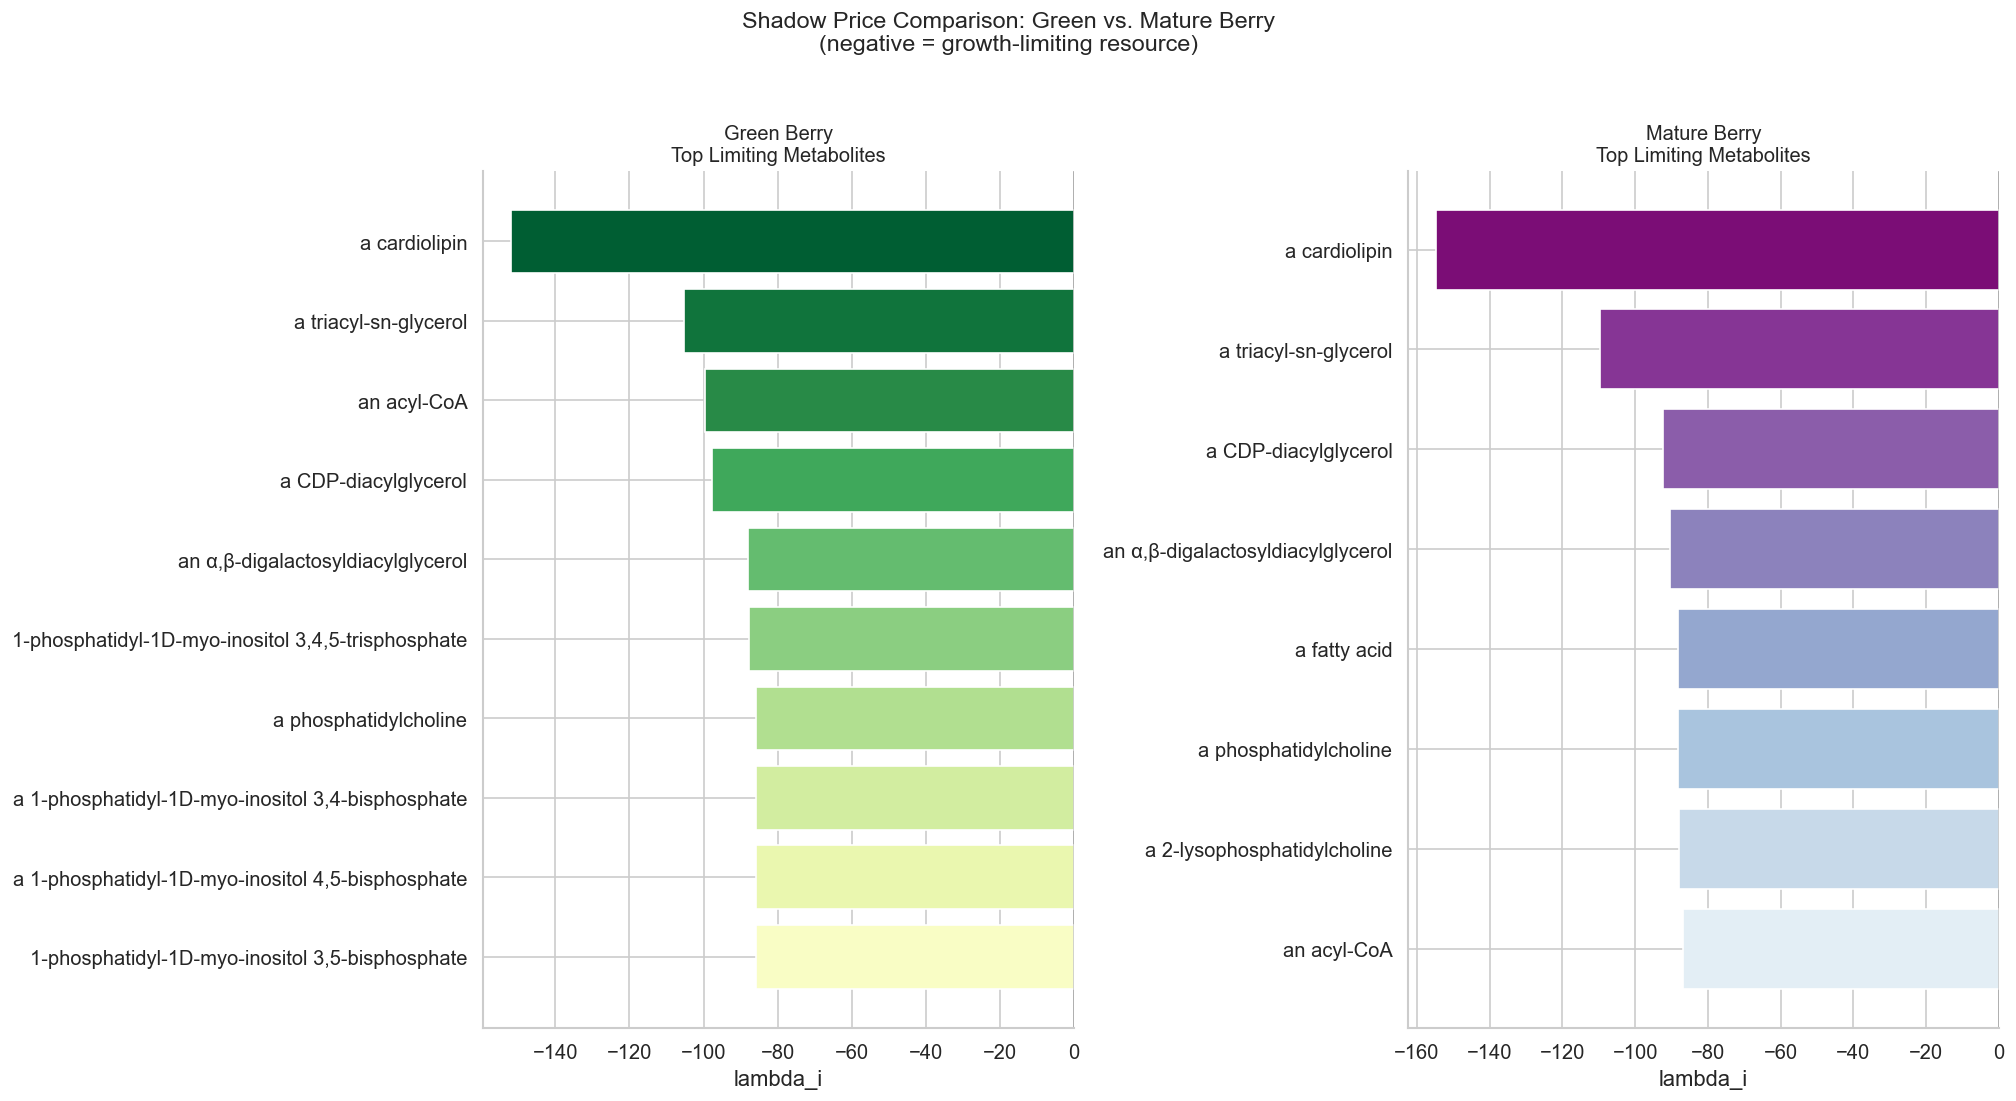

In [16]:
fig, axes = plt.subplots(1, 2, figsize = (17, 9))

df_shadow_neg_g_agg = (df_shadow_neg_g
    .groupby('Metabolite', as_index=False)['Shadow Price']
    .min()
    .sort_values('Shadow Price'))

# Left
axes[0].barh(df_shadow_neg_g_agg['Metabolite'], 
             df_shadow_neg_g_agg['Shadow Price'],
             color = sns.color_palette('YlGn_r', len(df_shadow_neg_g_agg)), 
             edgecolor = 'white')
axes[0].axvline(0, color = 'black', lw = 0.8)
axes[0].set_xlabel('lambda_i')
axes[0].set_title('Green Berry\nTop Limiting Metabolites', fontsize = 12)
axes[0].invert_yaxis()

# Right
df_shadow_neg_m_agg = (df_shadow_neg_m
    .groupby('Metabolite', as_index=False)['Shadow_M']
    .min()
    .sort_values('Shadow_M'))

axes[1].barh(df_shadow_neg_m_agg['Metabolite'],
             df_shadow_neg_m_agg['Shadow_M'],
             color     = sns.color_palette('BuPu_r', len(df_shadow_neg_m_agg)),
             edgecolor = 'white')
axes[1].axvline(0, color = 'black', lw = 0.8)
axes[1].set_xlabel('lambda_i')
axes[1].set_title('Mature Berry\nTop Limiting Metabolites', fontsize = 12)
axes[1].invert_yaxis()

plt.suptitle('Shadow Price Comparison: Green vs. Mature Berry\n'
             '(negative = growth-limiting resource)',
             fontsize = 14, y = 1.02)
plt.tight_layout()
# plt.savefig('fig5_stage_shadow_comparison.png', dpi = 150, bbox_inches = 'tight')
plt.show()

### 3.7 Carbon-Growth Coupling Comparison

The relationship between sucrose uptake rate and maximum biomass flux is characterised for both stages across a sucrose scan ($0.1$–$5.0\, mmol/gDW/h$) to compare carbon use efficiency.

Both stages show a perfectly linear carbon-growth relationship ($R^2 = 1.0$), confirming that sucrose is the sole limiting carbon source in both models. The mature berry has a marginally higher carbon efficiency ($slope = 0.1591$ vs $0.1532\, h^{-1}/(mmol/gDW/h)$) — a $3.9\%$ improvement — consistent with the metabolic optimisation associated with the shift from growth to maintenance and sugar accumulation at maturation.

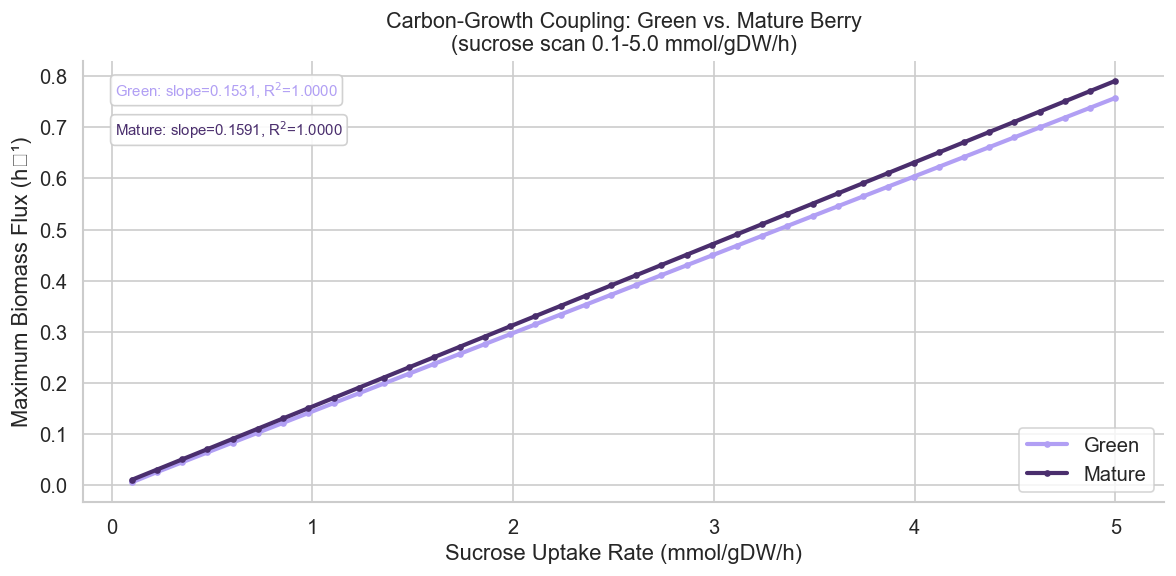


Carbon-growth coupling summary:
  Green: slope = 0.15315, intercept = -0.00859, R2 = 1.000000
  Mature: slope = 0.15909, intercept = -0.00497, R2 = 1.000000


In [17]:
suc_scan = np.linspace(0.1, 5.0, 40)
results_comparison = []

for rate in suc_scan:
    for name, model in [('Green', green_model), ('Mature', mature_model)]:
        suc_rxn = next((r.id for r in model.exchanges
                        if 'SUCROSE' in r.id.upper()), None)
        if suc_rxn:
            with model:
                model.reactions.get_by_id(suc_rxn).lower_bound = -rate
                sol = model.optimize()
                results_comparison.append({'Sucrose Rate': rate,
                                           'Stage'       : name,
                                           'Biomass'     : sol.objective_value if sol.status=='optimal' else np.nan})

df_compare_robust = pd.DataFrame(results_comparison)

slopes = {}
for stage, grp in df_compare_robust.groupby('Stage'):
    valid = grp.dropna(subset = ['Biomass'])
    if len(valid) > 2:
        c = np.polyfit(valid['Sucrose Rate'].values, valid['Biomass'].values, 1)
        r2 = 1 - np.sum((valid['Biomass'].values - np.polyval(c, valid['Sucrose Rate'].values))**2) / \
                 np.sum((valid['Biomass'].values - valid['Biomass'].values.mean())**2)
        slopes[stage] = {'slope': c[0], 'intercept': c[1], 'r2': r2}

fig, ax      = plt.subplots(figsize=(10, 5))
colors_stage = {'Green': '#B19FF4', 'Mature': '#4A2E6D'}
for stage, grp in df_compare_robust.groupby('Stage'):
    valid = grp.dropna(subset=['Biomass'])
    ax.plot(valid['Sucrose Rate'], 
            valid['Biomass'],
            color      = colors_stage.get(stage, 'grey'), 
            lw         = 2.5, 
            marker     = 'o', 
            markersize = 3,
            label      = stage)
    if stage in slopes:
        s = slopes[stage]
        ax.annotate(f'{stage}: slope={s["slope"]:.4f}, R$^2$={s["r2"]:.4f}',
                    xy       = (0.03, 0.92 if stage == 'Green' else 0.83),
                    xycoords = 'axes fraction', 
                    fontsize = 9, 
                    color    = colors_stage.get(stage),
                    bbox     = dict(boxstyle = 'round, pad=0.3', fc = 'white', ec = '#ccc', alpha = 0.9))

ax.set_xlabel('Sucrose Uptake Rate (mmol/gDW/h)')
ax.set_ylabel('Maximum Biomass Flux (h⁻¹)')
ax.set_title('Carbon-Growth Coupling: Green vs. Mature Berry\n'
             '(sucrose scan 0.1-5.0 mmol/gDW/h)', fontsize = 13)
ax.legend()
plt.tight_layout()
# plt.savefig('fig6_stage_robustness_comparison.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print('\nCarbon-growth coupling summary:')
for stage, s in slopes.items():
    print(f'  {stage}: slope = {s["slope"]:.5f}, intercept = {s["intercept"]:.5f}, R2 = {s["r2"]:.6f}')

GROWTH_SLOPE_GREEN  = slopes.get('Green',  {}).get('slope', None)
GROWTH_SLOPE_MATURE = slopes.get('Mature', {}).get('slope', None)

## 4. Phenotypic Phase Plane Analysis

The phenotypic phase plane (PhPP) maps the maximum biomass flux as a function of O₂ uptake rate to identify the aerobic–fermentative transition boundary in the green berry.

The aerobic–fermentative transition occurs at $O_2 \approx 3.713\, mmol/gDW/h$, which coincides exactly with the FBA-optimal O₂ uptake. This means the green berry operates precisely at the aerobic boundary under default conditions — any reduction in O₂ availability immediately pushes the model into fermentative metabolism. This is biologically relevant for *A. niger* infection: fungal O₂ consumption could trigger anaerobic conditions in the green berry before *veraison*, unlike the mature berry which uses less O₂ and has a wider aerobic buffer.

PhPP computed: 40 points
O₂ column: EX_OXYGEN-MOLECULE_drain


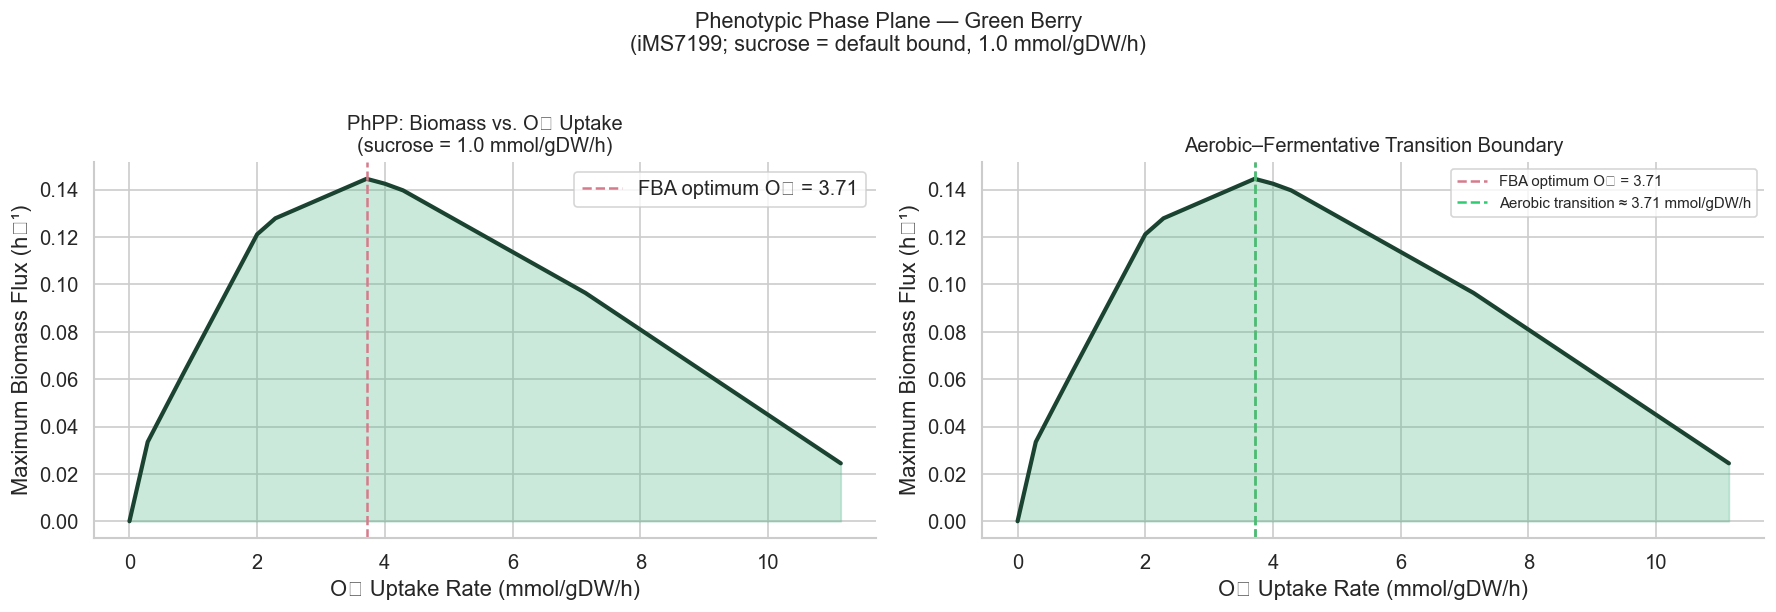

Aerobic–fermentative transition at O₂ ≈ 3.713 mmol/gDW/h
FBA-optimum O₂ = 3.713 mmol/gDW/h


In [18]:
if O2_RXN:
    N_ENVELOPE_PTS = 40
    o2_scan_max    = max(O2_BASELINE_GREEN * 3.0, 10.0)

    with green_model:
        green_model.reactions.get_by_id(O2_RXN).lower_bound = -o2_scan_max
        green_model.reactions.get_by_id(O2_RXN).upper_bound = 0
        env_g = production_envelope(green_model, reactions=[O2_RXN], points=N_ENVELOPE_PTS)

    o2_col = O2_RXN
    mu_col = 'flux_maximum'

    x_o2 = env_g[o2_col].abs()
    y_mu = env_g[mu_col]
    sort_idx = np.argsort(x_o2.values)
    x_o2 = x_o2.iloc[sort_idx]
    y_mu = y_mu.iloc[sort_idx]

    print(f'PhPP computed: {len(env_g)} points')
    print(f'O₂ column: {o2_col}')

# Transition detection
x_arr = x_o2.values
y_arr = y_mu.values
valid = ~(np.isnan(x_arr) | np.isnan(y_arr))
x_v, y_v = x_arr[valid], y_arr[valid]

o2_transition_g = None
if len(x_v) > 2:
    slope     = np.gradient(y_v, x_v)
    max_slope = slope.max()
    sat_idx   = np.where(slope < 0.05 * max_slope)[0]
    o2_transition_g = float(x_v[sat_idx[0]]) if len(sat_idx) > 0 else None

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax in axes:
    ax.fill_between(x_o2, 0, y_mu, color='#52B788', alpha=0.3)
    ax.plot(x_o2, y_mu, color='#1B4332', lw=2.5)
    ax.axvline(O2_BASELINE_GREEN, color='#D67B8C', ls='--', lw=1.5,
               label=f'FBA optimum O₂ = {O2_BASELINE_GREEN:.2f}')
    ax.set_xlabel('O₂ Uptake Rate (mmol/gDW/h)')
    ax.set_ylabel('Maximum Biomass Flux (h⁻¹)')

if o2_transition_g:
    axes[1].axvline(o2_transition_g, color='#2ecc71', ls='--', lw=1.5,
                    label=f'Aerobic transition ≈ {o2_transition_g:.2f} mmol/gDW/h')

axes[0].set_title('PhPP: Biomass vs. O₂ Uptake\n(sucrose = 1.0 mmol/gDW/h)', fontsize=12)
axes[0].legend()
axes[1].set_title('Aerobic–Fermentative Transition Boundary', fontsize=12)
axes[1].legend(fontsize=9)

plt.suptitle('Phenotypic Phase Plane — Green Berry\n'
             '(iMS7199; sucrose = default bound, 1.0 mmol/gDW/h)',
             fontsize=13, y=1.02)
plt.tight_layout()
# plt.savefig('fig3_green_phpp.png', dpi=150, bbox_inches='tight')
plt.show()

if o2_transition_g:
    print(f'Aerobic–fermentative transition at O₂ ≈ {o2_transition_g:.3f} mmol/gDW/h')
print(f'FBA-optimum O₂ = {O2_BASELINE_GREEN:.3f} mmol/gDW/h')

## 5. Model Export

Export the curated model in SBML format (`VvG_green_curated.xml`) and perform a round-trip validation to ensure structural and functional consistency. FBA was re-run after re-import, and growth rate consistency was confirmed.

In [19]:
final_sol_g = green_model.optimize()
assert final_sol_g.status == 'optimal', 'Curated model is infeasible.'
print(f'Curated model status : {final_sol_g.status}')
print(f'Biomass flux (μ)     : {final_sol_g.objective_value:.4f} h⁻¹')

Curated model status : optimal
Biomass flux (μ)     : 0.1446 h⁻¹


In [20]:
EXPORT_PATH = 'VvG_green_curated.xml'
write_sbml_model(green_model, EXPORT_PATH)
print(f'Exported: {EXPORT_PATH}  ({os.path.getsize(EXPORT_PATH)/1024:.1f} kB)')

_rt_model = read_sbml_model(EXPORT_PATH)
_rt_sol   = _rt_model.optimize()

_rt_renamed   = sum(1 for r in _rt_model.reactions  if r.id.startswith('R_'))
_orig_renamed = sum(1 for r in green_model.reactions if r.id.startswith('R_'))

assert _rt_sol.status == 'optimal',                                        'Round-trip model infeasible.'
assert abs(_rt_sol.objective_value - final_sol_g.objective_value) < 1e-6,  'Round-trip μ mismatch.'
assert 'e' in _rt_model.compartments,                                      'Extracellular compartment missing.'
assert len(_rt_model.reactions)   == len(green_model.reactions),           'Reaction count mismatch.'
assert len(_rt_model.metabolites) == len(green_model.metabolites),         'Metabolite count mismatch.'
assert _rt_renamed == _orig_renamed,                                       'Renaming curation lost.'

print('Round-trip integrity check PASSED')
print(f'    μ          : {final_sol_g.objective_value:.4f} → {_rt_sol.objective_value:.4f}')
print(f'    Reactions  : {len(_rt_model.reactions)}')
print(f'    Metabolites: {len(_rt_model.metabolites)}')
print(f'    R_ renamed : {_rt_renamed} reactions preserved')

Exported: VvG_green_curated.xml  (12257.3 kB)
Round-trip integrity check PASSED
    μ          : 0.1446 → 0.1446
    Reactions  : 4495
    Metabolites: 4399
    R_ renamed : 218 reactions preserved


## 6. Model Limitations

1. **Model curation:** $218$ reaction IDs were prefixed with `R_` to resolve Gurobi LP variable name conflicts, and compartment codes `C001`–`C010` were remapped to semantic identifiers (`C009 → 'e'` required for COBRApy boundary-reaction detection). Bounds and growth rate are unaffected by both operations.
2. **Single mass balance error:** `RXN0-5184__chlo` carries a stoichiometric discrepancy of C: $−84$, H: $−140$, O: $−70$ — the same artefact present in the mature berry model, confirming it is a persistent *iMS7199* reconstruction issue.
3. **Subsystem annotation errors:** Several reactions carry labels inherited from non-plant databases. No functional impact on flux calculations.
4. **Static medium:** The model uses fixed exchange bounds.
5. **Absence of transcriptional regulation:** Infection-induced transcriptional reprogramming is not captured at the constraint-based level.

## 7. References

* **iMS7199** (Sampaio, M., Rocha, M., & Dias, O., 2024)

Sampaio, M., Rocha, M., & Dias, O. (2024). iMS7199 – genome-scale metabolic
model of *Vitis vinifera* (Model ID MODEL2408120001). [Data set]. BioModels.
https://biomodels.org/MODEL2408120001